# Chapter 4 — Interlude: Probability, Likelihood and Bayes

This notebook accompanies **Chapter 4** of *Inference in Statistical Modelling and Machine Learning*.

## Key ideas

The chapter introduces three concepts that underpin the rest of the book.

- The **likelihood** of a hypothesis $H$ given data $D$ is the conditional probability of the data under that hypothesis: $\mathcal{L}(H;\,D) = \Pr(D \mid H)$.
- The **principle of maximum likelihood** recommends choosing the hypothesis that makes the observed data most probable. It often gives good guidance, but can fail when competing hypotheses differ greatly in prior plausibility.
- **Bayesian inference** provides a principled alternative: start with a **prior** probability for each hypothesis, observe the data, and update to a **posterior** via Bayes' theorem.

The running example throughout is a single ringing alarm bell — and what it actually tells you.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---
## 1 · The alien invasion detector

> **Book link — §4.1.**  An alarm bell rings at noon. The detector's specification: if an invasion is underway it rings with probability 1 (no misses); if no invasion is underway it rings with probability 0.01 (1% false-alarm rate). What should you conclude?

We have two competing hypotheses: $H_\text{inv}$ (invasion in progress) and $H_\text{null}$ (no invasion). The data $D$ is the fact that the alarm is ringing. The **likelihood** of each hypothesis is the probability it assigns to $D$:

$$\mathcal{L}(H;\,D) = \Pr(D \mid H).$$

Likelihoods after the alarm rings:
  L(H_inv;  D) = P(alarm | H_inv)  = 1.00
  L(H_null; D) = P(alarm | H_null) = 0.01

Likelihood ratio: 100:1 in favour of H_inv
Maximum likelihood conclusion: H_inv (invasion is underway)


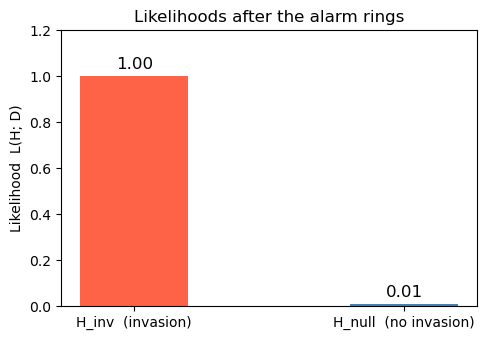

In [2]:
# Detector specification
p_alarm_given_inv  = 1.00   # P(alarm | H_inv)  — no misses
p_alarm_given_null = 0.01   # P(alarm | H_null) — false-alarm rate

# Likelihoods: L(H; D) = P(D | H)
L_inv  = p_alarm_given_inv
L_null = p_alarm_given_null

print('Likelihoods after the alarm rings:')
print(f'  L(H_inv;  D) = P(alarm | H_inv)  = {L_inv:.2f}')
print(f'  L(H_null; D) = P(alarm | H_null) = {L_null:.2f}')
print(f'\nLikelihood ratio: {L_inv / L_null:.0f}:1 in favour of H_inv')
print('Maximum likelihood conclusion: H_inv (invasion is underway)')

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(['H_inv  (invasion)', 'H_null  (no invasion)'],
       [L_inv, L_null],
       color=['tomato', 'steelblue'], width=0.4)
ax.set_ylabel('Likelihood  L(H; D)')
ax.set_title('Likelihoods after the alarm rings')
ax.set_ylim(0, 1.2)
for i, v in enumerate([L_inv, L_null]):
    ax.text(i, v + 0.03, f'{v:.2f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

The maximum likelihood hypothesis is $H_\text{inv}$: its likelihood is 100 times larger than $H_\text{null}$'s. But likelihoods say nothing about how *plausible* each hypothesis was before the alarm rang. If an alien invasion was a one-in-a-million chance a moment ago, should a single ringing bell really change your mind?

> **Book link — Exercise 4.2.**  The log-product score we maximised in Chapter 3 is the logarithm of the relevant likelihood function. Choosing $k$ by maximising the training log-product score is therefore a form of maximum likelihood inference — which, as we are about to see, is not always trustworthy.

---
## 2 · Likelihood vs posterior: why prior plausibility matters

To find the probability of $H_\text{inv}$ *given* that the alarm rang, we apply **Bayes' theorem**:

$$\Pr(H \mid D) = \frac{\mathcal{L}(H;\,D)\;\Pr(H)}{\Pr(D)},$$

where $\Pr(D) = \mathcal{L}(H_\text{inv};\,D)\,\Pr(H_\text{inv}) + \mathcal{L}(H_\text{null};\,D)\,\Pr(H_\text{null})$ is the total probability of the alarm ringing. $\Pr(H)$ is the **prior** — our degree of belief in hypothesis $H$ before seeing the data — and $\Pr(H \mid D)$ is the **posterior**.

Prior = 1e-6  ->  posterior = 1.00e-04  (H_null still overwhelmingly dominant)
Prior = 0.1   ->  posterior = 0.917   (H_inv now the most probable hypothesis)


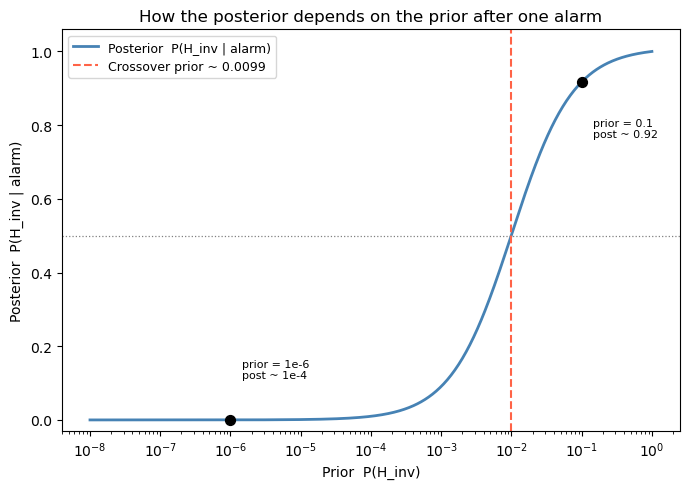

In [3]:
def posterior_inv(prior, false_alarm_rate=0.01):
    """Posterior P(H_inv | alarm) via Bayes' theorem."""
    evidence = 1.0 * prior + false_alarm_rate * (1 - prior)
    return prior / evidence

def posterior_N_detectors(prior, N, false_alarm_rate=0.01):
    """Posterior when N independent detectors all alarm."""
    return posterior_inv(prior, false_alarm_rate=false_alarm_rate ** N)

# Two priors discussed in the chapter
prior_1em6 = 1e-6   # one-in-a-million
prior_0p1  = 0.1    # one-in-ten

post_1em6 = posterior_inv(prior_1em6)
post_0p1  = posterior_inv(prior_0p1)
print(f'Prior = 1e-6  ->  posterior = {post_1em6:.2e}  (H_null still overwhelmingly dominant)')
print(f'Prior = 0.1   ->  posterior = {post_0p1:.3f}   (H_inv now the most probable hypothesis)')

# Posterior as a continuous function of the prior
prior_grid = np.logspace(-8, -0.001, 600)
post_grid  = posterior_inv(prior_grid)

# Crossover located numerically (derived analytically in Exercise 1)
crossover = prior_grid[np.argmin(np.abs(post_grid - 0.5))]

fig, ax = plt.subplots(figsize=(7, 5))
ax.semilogx(prior_grid, post_grid, 'steelblue', linewidth=2,
            label='Posterior  P(H_inv | alarm)')
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.9)
ax.axvline(crossover, color='tomato', linestyle='--', linewidth=1.5,
           label=f'Crossover prior ~ {crossover:.4f}')

for p, post, txt, dy in [
        (prior_1em6, post_1em6, 'prior = 1e-6\npost ~ 1e-4',  30),
        (prior_0p1,  post_0p1,  f'prior = 0.1\npost ~ {post_0p1:.2f}', -40)]:
    ax.scatter(p, post, color='k', s=50, zorder=5)
    ax.annotate(txt, (p, post), textcoords='offset points',
                xytext=(8, dy), fontsize=8)

ax.set_xlabel('Prior  P(H_inv)')
ax.set_ylabel('Posterior  P(H_inv | alarm)')
ax.set_title('How the posterior depends on the prior after one alarm')
ax.set_ylim(-0.03, 1.06)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

With a prior of $10^{-6}$, the alarm multiplies the probability of invasion a hundredfold — but $10^{-4}$ is still tiny, and $H_\text{null}$ remains far more credible. The maximum likelihood conclusion ($H_\text{inv}$) is misleading here.

With a prior of $0.1$, the story is different: the posterior for $H_\text{inv}$ reaches roughly $0.92$, making $H_\text{inv}$ the clear winner. The alarm is decisive when the invasion was already a plausible prospect.

---
## 3 · When maximum likelihood is reliable: accumulating evidence

> **Book link — §4.2.**  Suppose you have $N$ independent detectors, each with a 1% false-alarm rate, and all $N$ alarms ring simultaneously. The joint likelihood of $H_\text{null}$ is $0.01^N$, which shrinks rapidly. Even a prior as low as $10^{-6}$ is eventually overwhelmed by enough independent evidence.

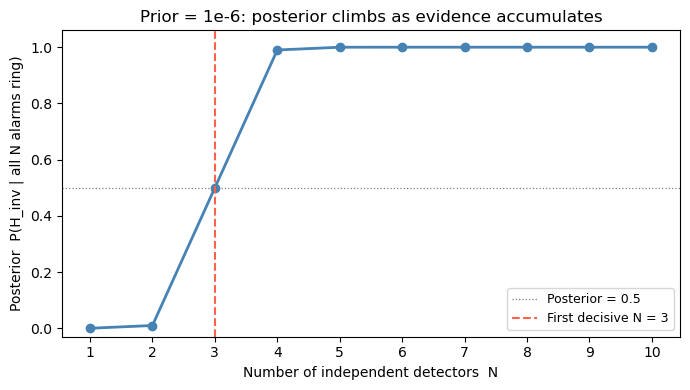

Prior = 1e-6:  posterior first exceeds 0.5 at N = 3

  N =  1:  L(H_null) = 0.01^1 = 1e-02,  posterior = 0.0001
  N =  2:  L(H_null) = 0.01^2 = 1e-04,  posterior = 0.0099
  N =  3:  L(H_null) = 0.01^3 = 1e-06,  posterior = 0.5000
  N =  4:  L(H_null) = 0.01^4 = 1e-08,  posterior = 0.9901
  N =  5:  L(H_null) = 0.01^5 = 1e-10,  posterior = 0.9999
  N =  6:  L(H_null) = 0.01^6 = 1e-12,  posterior = 1.0000
  N =  7:  L(H_null) = 0.01^7 = 1e-14,  posterior = 1.0000
  N =  8:  L(H_null) = 0.01^8 = 1e-16,  posterior = 1.0000
  N =  9:  L(H_null) = 0.01^9 = 1e-18,  posterior = 1.0000
  N = 10:  L(H_null) = 0.01^10 = 1e-20,  posterior = 1.0000


In [4]:
N_range = np.arange(1, 11)
posts_N = [posterior_N_detectors(prior_1em6, n) for n in N_range]

n_decisive = next(n for n, p in zip(N_range, posts_N) if p >= 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(N_range, posts_N, 'o-', color='steelblue', linewidth=2)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.9, label='Posterior = 0.5')
ax.axvline(n_decisive, color='tomato', linestyle='--', linewidth=1.5,
           label=f'First decisive N = {n_decisive}')
ax.set_xlabel('Number of independent detectors  N')
ax.set_ylabel('Posterior  P(H_inv | all N alarms ring)')
ax.set_title('Prior = 1e-6: posterior climbs as evidence accumulates')
ax.set_ylim(-0.03, 1.06)
ax.set_xticks(N_range)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Prior = 1e-6:  posterior first exceeds 0.5 at N = {n_decisive}')
print()
for n in N_range:
    print(f'  N = {n:2d}:  L(H_null) = 0.01^{n} = {0.01**n:.0e},  posterior = {posts_N[n-1]:.4f}')

Even with a prior as low as $10^{-6}$, just three independent alarms push the posterior past $0.5$, and at $N = 4$ it already exceeds $0.99$. The likelihood of $H_\text{null}$ has shrunk to $10^{-8}$ — far smaller than the prior odds of $10^{-6}$. This is the regime in which maximum likelihood inference can be trusted: sufficient independent evidence overwhelms even a deeply sceptical prior.

---
## Exercises

### Exercise 1 — The crossover prior

For what value of $\Pr(H_\text{inv})$ is the posterior $\Pr(H_\text{inv} \mid D)$ exactly $0.5$? Derive a formula for this crossover prior in terms of $\mathcal{L}(H_\text{inv};\,D)$ and $\mathcal{L}(H_\text{null};\,D)$, and evaluate it for the alien detector. Check that your result agrees with the figure from §2.

In [5]:
# Your answer here


In [ ]:
# Solution
#
# Set the posterior equal to 0.5:
#
#   L_inv * p / (L_inv * p + L_null * (1 - p)) = 0.5
#
# Solve for p gives
#
#   p = L_null / (L_inv + L_null)

crossover_exact = L_null / (L_inv + L_null)
print(f'Crossover prior  p* = L_null / (L_inv + L_null)')
print(f'                    = {L_null} / ({L_inv} + {L_null})')
print(f'                    = {crossover_exact:.6f}')
print()
print(f'Verification:  posterior_inv(p*) = {posterior_inv(crossover_exact):.6f}  (should be 0.5)')
print(f'Agrees with figure from §2:       crossover marked at ~ {crossover:.4f}')

# Interpretation: if your prior is above ~0.0099 (roughly 1 in 101), the posterior
# for H_inv exceeds 0.5 after a single alarm — and maximum likelihood gives the
# right answer.  Below that prior, H_null remains more probable even after the alarm.

Crossover prior  p* = L_null / (L_inv + L_null)
                    = 0.01 / (1.0 + 0.01)
                    = 0.009901

Verification:  posterior_inv(p*) = 0.500000  (should be 0.5)
Agrees with figure from §2:       crossover marked at ~ 0.0099


### Exercise 2 — How many detectors does it take?

With $N$ independent detectors (each with a 1% false-alarm rate) and prior $\Pr(H_\text{inv}) = 10^{-6}$, find analytically the smallest $N$ such that the posterior reaches at least 0.5. Then plot the posterior against $N$ for three different priors — $10^{-2}$, $10^{-4}$, and $10^{-6}$ — on a single figure, to show how the required number of detectors shifts with the prior.

In [7]:
# Your answer here


Analytical minimum N for posterior >= 0.5:
  prior = 1e-02:  N_exact = 1.00  ->  N_min = 1
  prior = 1e-04:  N_exact = 2.00  ->  N_min = 2
  prior = 1e-06:  N_exact = 3.00  ->  N_min = 3


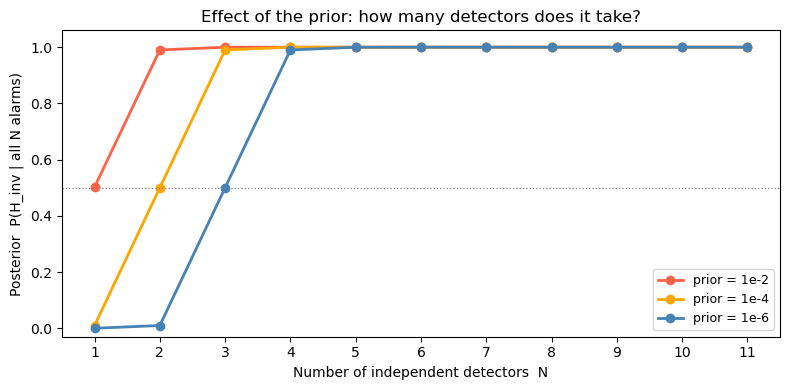

In [8]:
# Solution
#
# The posterior reaches 0.5 when (from Exercise 1 with L_null -> 0.01^N):
#
#   0.01^N = prior / (1 - prior)   [= prior odds]
#   N * log(0.01) = log(prior / (1 - prior))
#   N >= log(prior / (1 - prior)) / log(0.01)

priors_ex2 = [1e-2, 1e-4, 1e-6]

print('Analytical minimum N for posterior >= 0.5:')
for p in priors_ex2:
    prior_odds  = p / (1 - p)
    N_exact     = np.log(prior_odds) / np.log(0.01)
    N_min       = int(np.ceil(N_exact))
    print(f'  prior = {p:.0e}:  N_exact = {N_exact:.2f}  ->  N_min = {N_min}')

N_range_ex2 = np.arange(1, 12)
colors = ['tomato', 'orange', 'steelblue']
labels = ['prior = 1e-2', 'prior = 1e-4', 'prior = 1e-6']

fig, ax = plt.subplots(figsize=(8, 4))
for p, c, lbl in zip(priors_ex2, colors, labels):
    posts = [posterior_N_detectors(p, n) for n in N_range_ex2]
    ax.plot(N_range_ex2, posts, 'o-', color=c, linewidth=2, label=lbl)
ax.axhline(0.5, color='grey', linestyle=':', linewidth=0.9)
ax.set_xlabel('Number of independent detectors  N')
ax.set_ylabel('Posterior  P(H_inv | all N alarms)')
ax.set_title('Effect of the prior: how many detectors does it take?')
ax.set_ylim(-0.03, 1.06)
ax.set_xticks(N_range_ex2)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# A weaker prior shifts the transition to higher N, but the transition itself
# remains sharp once the joint likelihood ratio dominates the prior odds.

### Exercise 3 — A less reliable detector

Repeat the analyses of §2 and §3 using a false-alarm rate of 5% instead of 1%. Produce two figures side by side: the posterior-vs-prior curve (as in §2) and the posterior-vs-N curve for prior $= 10^{-6}$ (as in §3). How does the weaker detector change the crossover prior and the number of detectors needed for a confident conclusion?

In [9]:
# Your answer here


Crossover prior:  1% FAR -> 0.0099,  5% FAR -> 0.0476


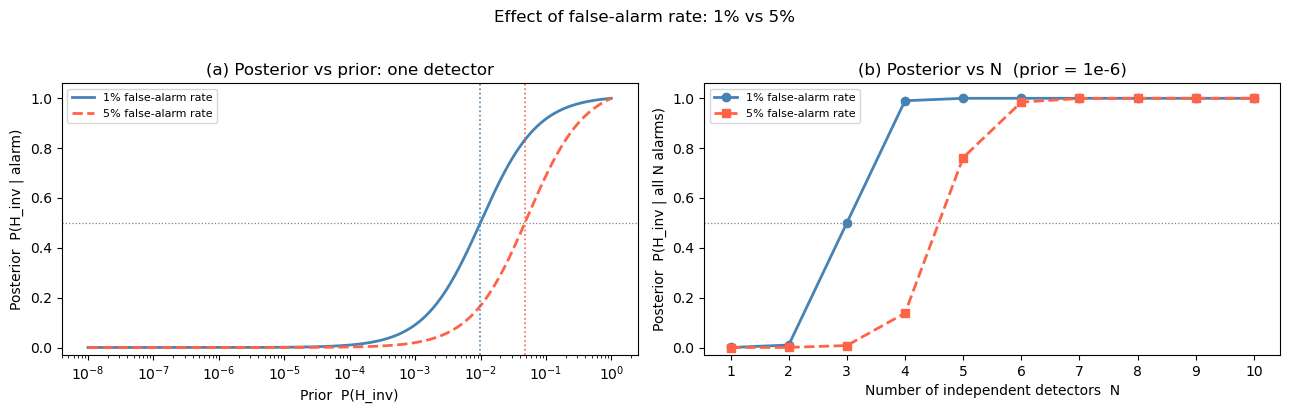

Posterior vs N  (prior = 1e-6):
    N     1% FAR     5% FAR
    1     0.0001     0.0000
    2     0.0099     0.0004
    3     0.5000     0.0079
    4     0.9901     0.1379
    5     0.9999     0.7619
    6     1.0000     0.9846
    7     1.0000     0.9992
    8     1.0000     1.0000
    9     1.0000     1.0000
   10     1.0000     1.0000


In [10]:
# Solution
FAR_new = 0.05

crossover_new = FAR_new / (1.0 + FAR_new)   # from Exercise 1 formula with L_inv=1
print(f'Crossover prior:  1% FAR -> {L_null / (L_inv + L_null):.4f},  '
      f'5% FAR -> {crossover_new:.4f}')

post_grid_new = posterior_inv(prior_grid, false_alarm_rate=FAR_new)
posts_N_new   = [posterior_N_detectors(prior_1em6, n, false_alarm_rate=FAR_new)
                 for n in N_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# (a) Posterior vs prior
axes[0].semilogx(prior_grid, post_grid,     'steelblue', lw=2,
                 label='1% false-alarm rate')
axes[0].semilogx(prior_grid, post_grid_new, 'tomato',    lw=2, linestyle='--',
                 label='5% false-alarm rate')
axes[0].axhline(0.5, color='grey', linestyle=':', lw=0.9)
axes[0].axvline(crossover,     color='steelblue', linestyle=':', lw=1.2)
axes[0].axvline(crossover_new, color='tomato',    linestyle=':', lw=1.2)
axes[0].set_xlabel('Prior  P(H_inv)')
axes[0].set_ylabel('Posterior  P(H_inv | alarm)')
axes[0].set_title('(a) Posterior vs prior: one detector')
axes[0].set_ylim(-0.03, 1.06)
axes[0].legend(fontsize=8)

# (b) Posterior vs N
axes[1].plot(N_range, posts_N,     'o-',  color='steelblue', lw=2,
             label='1% false-alarm rate')
axes[1].plot(N_range, posts_N_new, 's--', color='tomato',    lw=2,
             label='5% false-alarm rate')
axes[1].axhline(0.5, color='grey', linestyle=':', lw=0.9)
axes[1].set_xlabel('Number of independent detectors  N')
axes[1].set_ylabel('Posterior  P(H_inv | all N alarms)')
axes[1].set_title('(b) Posterior vs N  (prior = 1e-6)')
axes[1].set_ylim(-0.03, 1.06)
axes[1].set_xticks(N_range)
axes[1].legend(fontsize=8)

plt.suptitle('Effect of false-alarm rate: 1% vs 5%', y=1.02)
plt.tight_layout()
plt.show()

# Summary
print('Posterior vs N  (prior = 1e-6):')
print(f'  {"N":>3}   {"1% FAR":>8}   {"5% FAR":>8}')
for n, p1, p5 in zip(N_range, posts_N, posts_N_new):
    print(f'  {n:>3}   {p1:>8.4f}   {p5:>8.4f}')

# With a 5% false-alarm rate, the crossover prior shifts from ~0.0099 to ~0.0476
# — a single alarm is less informative.  For prior = 1e-6, the transition still
# happens at small N (around 4-5), but the posterior climbs more gradually.